# Fase 1 — Conhecendo os dados

**Companion: Nielsen, cap. 2 e 5 (encontrar e organizar dados temporais).**

Antes de qualquer modelo, é preciso entender *o que* estamos medindo. Este notebook apresenta as três séries do projeto — **IPCA**, **câmbio** e **Selic** — sob duas lentes que se complementam:

- **Econômica:** o que cada variável significa, de onde vem e por que importa.
- **Estatística:** como a série se comporta (nível, dispersão, sazonalidade, distribuição).

Todas vêm da API pública do **SGS — Sistema Gerenciador de Séries Temporais do Banco Central do Brasil**, sem necessidade de chave.

## Como os dados chegam até aqui

O módulo `loaders` baixa cada série da API do BCB e guarda um **snapshot Parquet** em `data/raw/`. Isso garante **reprodutibilidade**: as séries do BCB sofrem revisão ao longo do tempo, e o cache congela exatamente o estado usado na análise. Séries diárias (câmbio, Selic) são baixadas em blocos de até 10 anos (limite da API) e reamostradas para frequência mensal.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from series_eco.config import SGS_SERIES
from series_eco.data import loaders
from series_eco.eda import plots

painel = loaders.load_panel("2000-01-01")
ipca, cambio, selic = painel["ipca"], painel["cambio"], painel["selic"]

print("Códigos das séries no SGS/BCB:", SGS_SERIES)
print(f"Período: {painel.index.min():%Y-%m} a {painel.index.max():%Y-%m}  ({len(painel)} meses)")
painel.head()

Códigos das séries no SGS/BCB: {'ipca': 433, 'cambio': 1, 'selic': 4189}
Período: 2000-01 a 2026-04  (316 meses)


,ipca,cambio,selic
Date,,,
2000-01-01,0.62,1.8024,18.94
2000-02-01,0.13,1.7685,18.87
2000-03-01,0.22,1.7473,18.85
2000-04-01,0.42,1.8067,18.62
2000-05-01,0.01,1.8266,18.51


## Ficha técnica das séries

| Variável | O que mede | Fonte (SGS) | Unidade | Frequência original |
|---|---|---|---|---|
| **IPCA** | Inflação ao consumidor (variação de preços de uma cesta de bens) | 433 | % ao mês | mensal |
| **Câmbio** | Preço do dólar americano em reais (venda) | 1 | R$/US$ | diária |
| **Selic** | Taxa básica de juros da economia (meta do Copom) | 4189 | % ao ano | diária |

Estatísticas descritivas do período:

In [2]:
painel.describe().round(3)

,ipca,cambio,selic
count,316.000,316.000,316.000
mean,0.497,3.213,12.323
std,0.392,1.346,4.885
min,-0.680,1.556,1.900
25%,0.258,2.050,9.115
50%,0.450,2.884,12.160
75%,0.670,4.136,14.920
max,3.020,6.192,26.320


## 1. IPCA — a inflação

**Economia:** o IPCA (Índice de Preços ao Consumidor Amplo), calculado pelo IBGE, é a inflação *oficial* do Brasil — a meta perseguida pelo Banco Central. A série 433 traz a **variação percentual mensal**: quanto os preços subiram (ou caíram) no mês.

**Estatística:** por já ser uma *taxa de variação*, tende a oscilar em torno de um patamar — sem a tendência explosiva de um índice de nível. Repare nos picos associados a choques (câmbio, alimentos, energia).

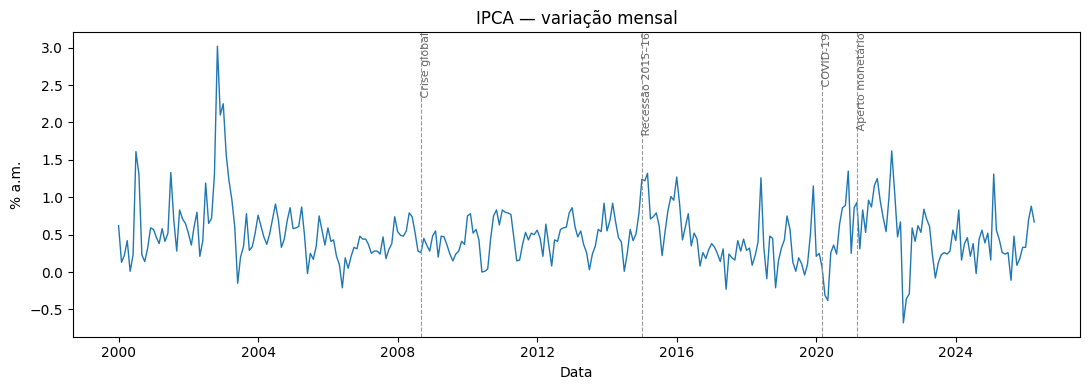

In [3]:
plots.plot_series(ipca, "IPCA — variação mensal", "% a.m.", events=plots.ECONOMIC_EVENTS)
plt.show()

### IPCA acumulado em 12 meses — a inflação "de manchete"

Somando as 12 variações mensais mais recentes, recuperamos o número que aparece no noticiário ("inflação de X% no ano"). É a mesma informação, em outra escala — e mostra os ciclos de alta e baixa de forma mais legível.

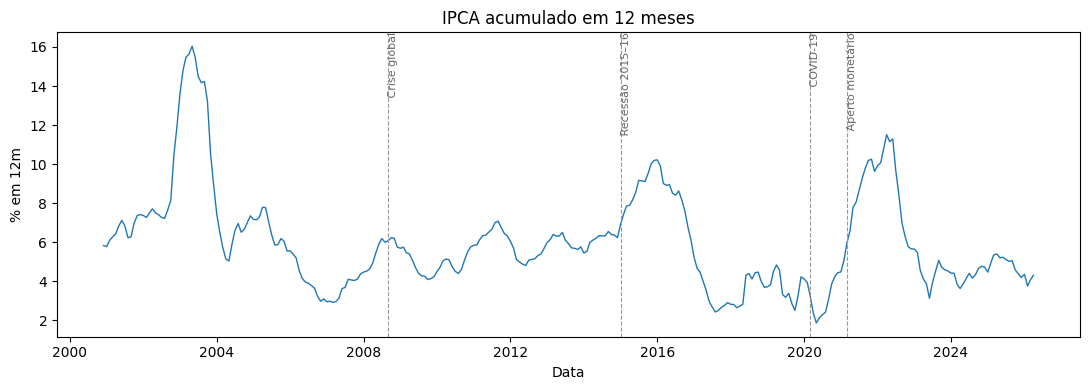

In [4]:
acum = plots.accumulated_12m(ipca)
plots.plot_series(acum, "IPCA acumulado em 12 meses", "% em 12m", events=plots.ECONOMIC_EVENTS)
plt.show()

### Distribuição e sazonalidade do IPCA

O histograma mostra a distribuição das variações mensais; o boxplot por mês revela o **padrão sazonal** — alguns meses (tipicamente início de ano, por reajustes) costumam ter inflação mais alta que outros.

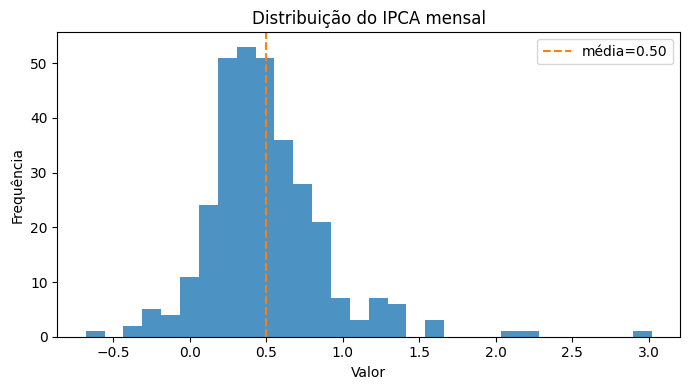

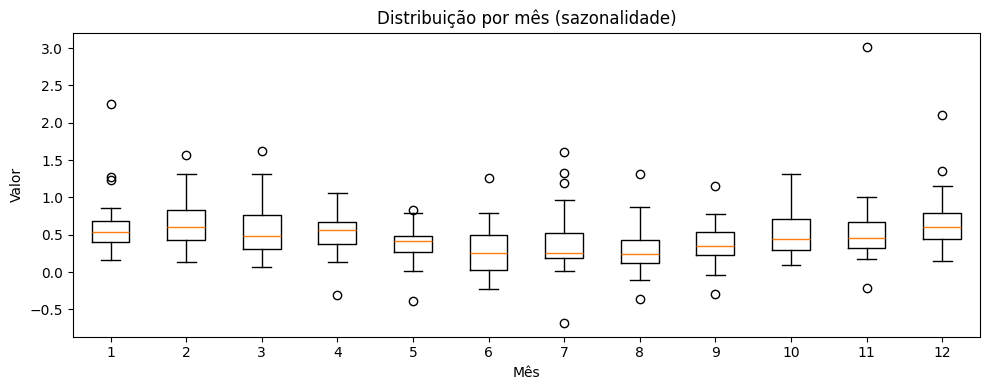

In [5]:
plots.plot_histogram(ipca, "Distribuição do IPCA mensal")
plt.show()
plots.plot_seasonal_subseries(ipca)
plt.show()

## 2. Câmbio — o dólar (R$/US$)

**Economia:** o preço do dólar afeta diretamente os preços de importados e commodities, sendo um canal clássico de repasse para a inflação. É uma variável de mercado, sensível a fluxo de capital, risco-país e juros.

**Estatística:** em **nível**, o câmbio tem forte tendência (não estacionário) — cresce ao longo dos anos. Por isso, na modelagem usaremos sua *variação* (primeira diferença).

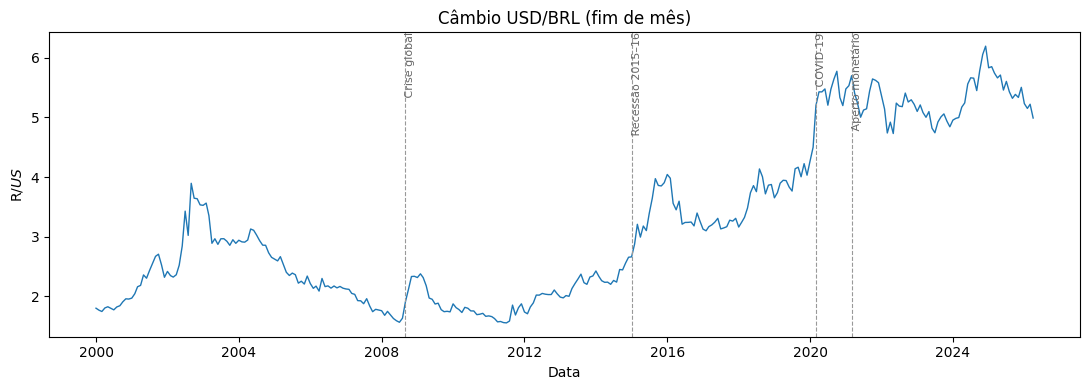

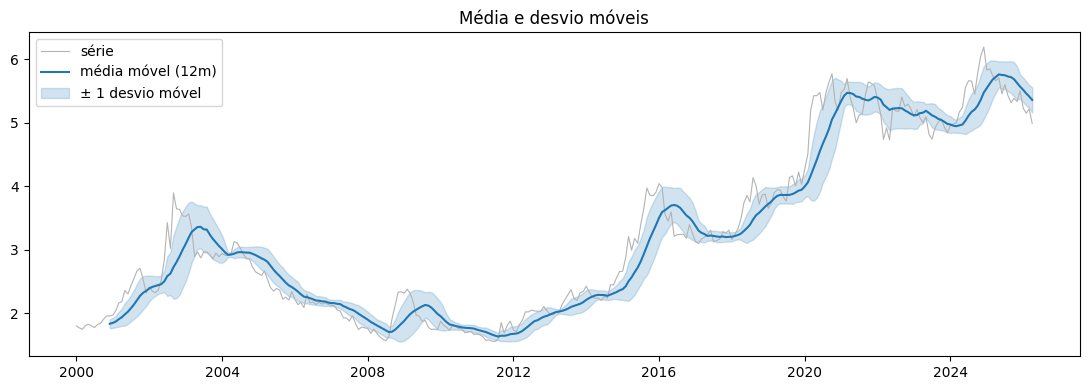

In [6]:
plots.plot_series(cambio, "Câmbio USD/BRL (fim de mês)", "R$/US$", events=plots.ECONOMIC_EVENTS)
plt.show()
plots.plot_rolling_stats(cambio, window=12)
plt.show()

> No gráfico de média/desvio móveis acima, a média móvel "anda" claramente ao longo do tempo — assinatura visual de **não estacionariedade**, que confirmaremos com testes formais na Fase 3.

## 3. Selic — a taxa de juros

**Economia:** a Selic é o principal instrumento de política monetária. O Banco Central a eleva para conter a inflação e a reduz para estimular a atividade. É decidida pelo Copom em reuniões periódicas — daí os "degraus" na série.

**Estatística:** série bastante persistente, com mudanças de patamar (regimes). Também a usaremos em variação nos modelos multivariados.

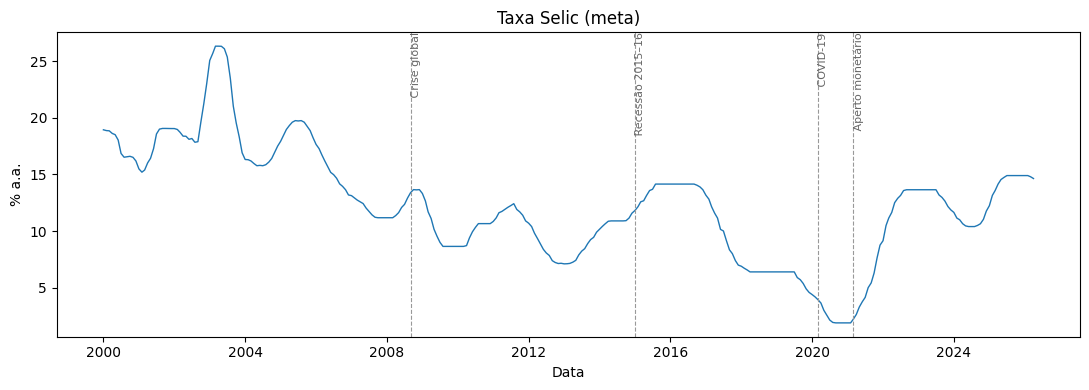

In [7]:
plots.plot_series(selic, "Taxa Selic (meta)", "% a.a.", events=plots.ECONOMIC_EVENTS)
plt.show()

## 4. As três juntas — quem antecede quem?

A teoria econômica sugere que variações de câmbio e juros *antecedem* movimentos da inflação. A correlação cruzada mede isso: para cada defasagem `k`, qual a correlação entre o IPCA de hoje e a variável `k` meses atrás. Um pico em `k>0` indica que a variável **lidera** o IPCA.

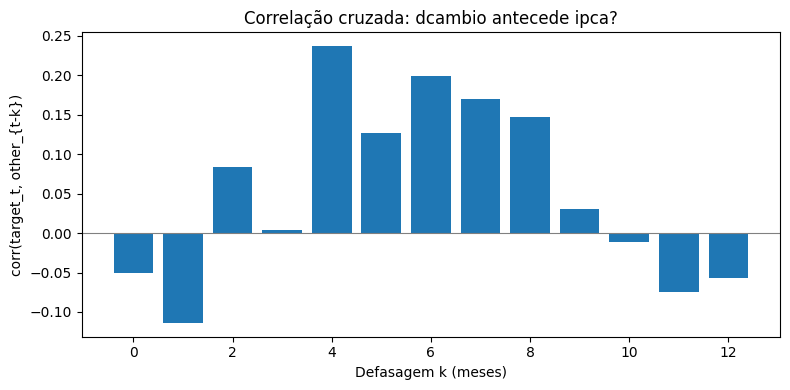

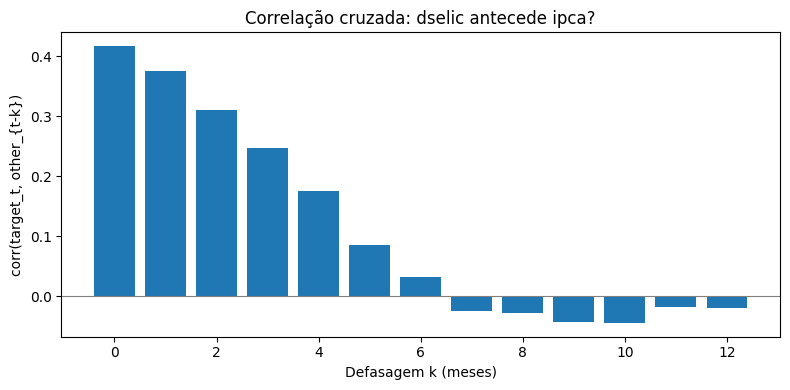

In [8]:
dcambio = cambio.diff().rename("dcambio")
dselic = selic.diff().rename("dselic")

plots.plot_cross_correlation(ipca.rename("ipca"), dcambio, maxlag=12)
plt.show()
plots.plot_cross_correlation(ipca.rename("ipca"), dselic, maxlag=12)
plt.show()

---
**Resumo:** já sabemos o que cada série mede, como ela se comporta e como se relacionam. O IPCA oscila em torno de um nível (candidato a estacionário); câmbio e Selic têm tendência (precisarão de diferenciação). A partir daqui, a Fase 2 aprofunda a EDA (decomposição e autocorrelação) e as fases seguintes constroem e avaliam modelos.